In [1]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### DOWNLOADING THE DATASET

In [2]:
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/nandan_rohilla/.cache/kagglehub/datasets/laotse/credit-risk-dataset/versions/1


### LOADING DATASET 

In [3]:
df_org = pd.read_csv('/Users/nandan_rohilla/.cache/kagglehub/datasets/laotse/credit-risk-dataset/versions/1/credit_risk_dataset.csv')

df_clean = df_org.dropna()




<function matplotlib.pyplot.show(close=None, block=None)>

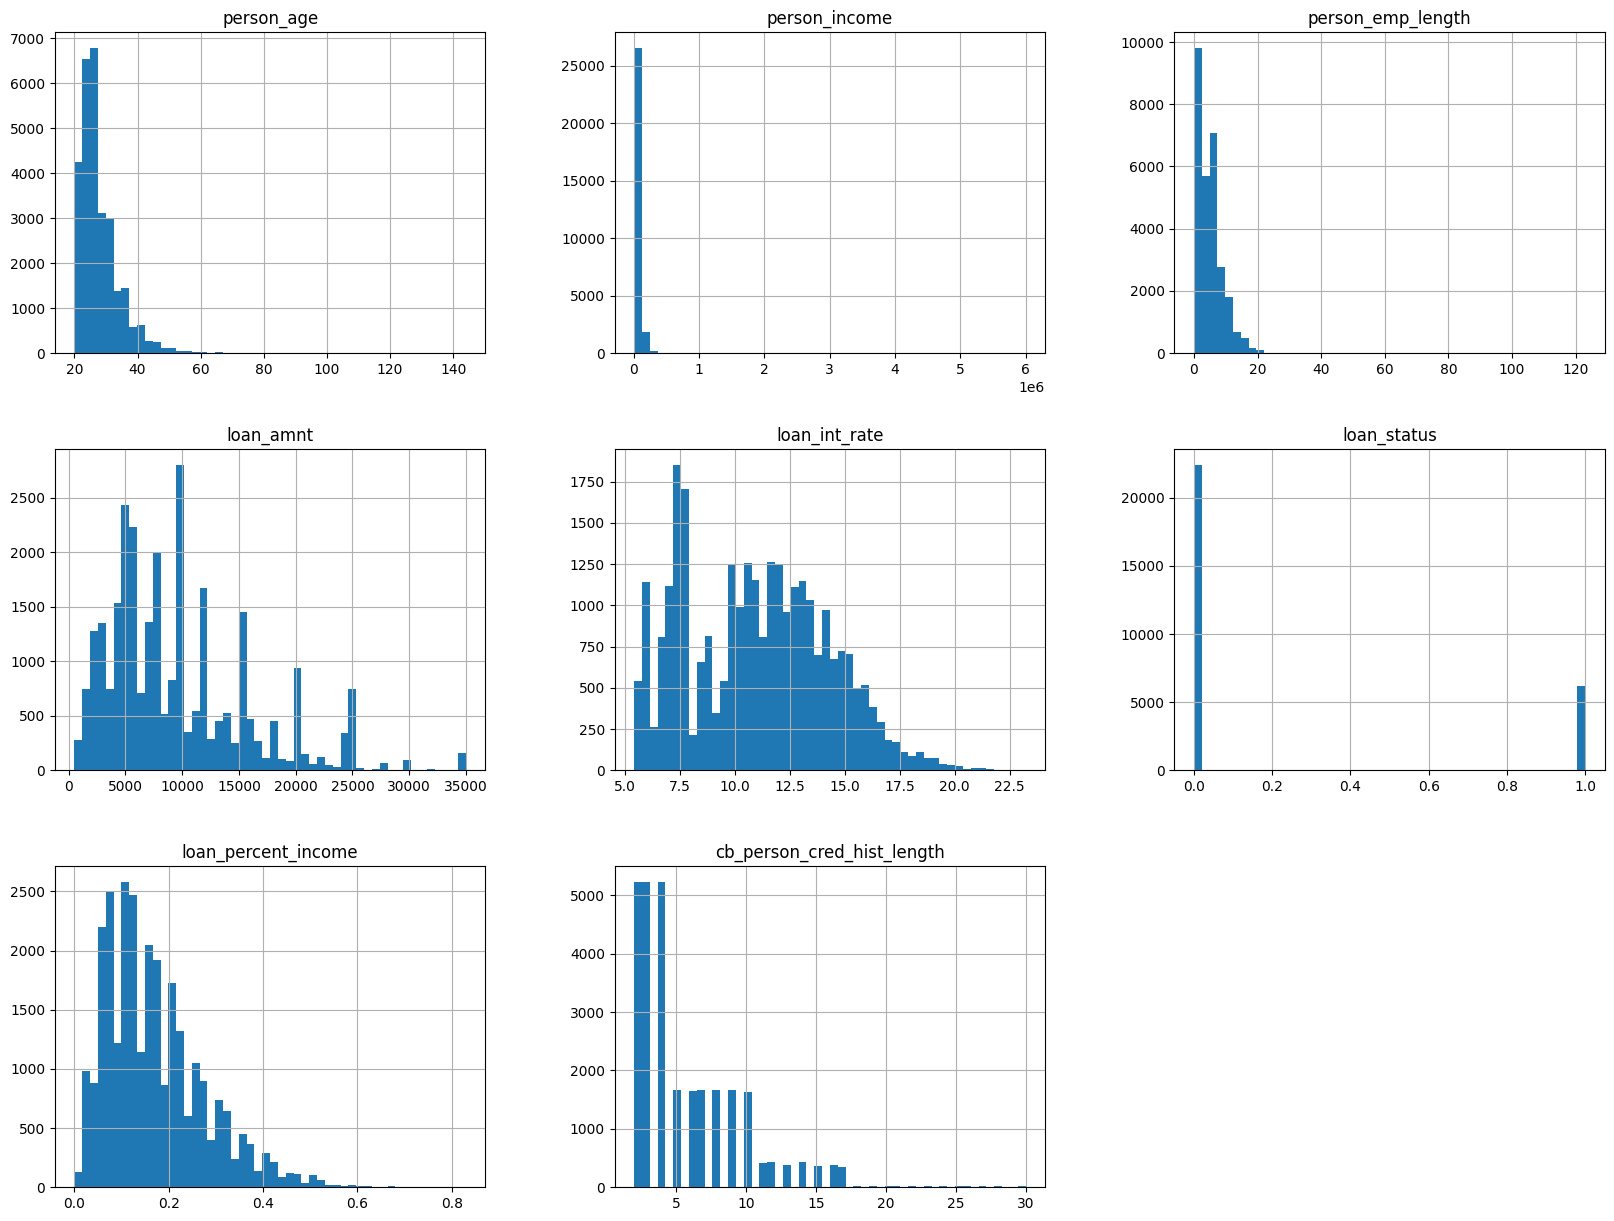

In [4]:
histogram_df = df_clean.hist(bins=50, figsize=(20,15))
plt.show

### FEATURES AND TRAINING FOR THE PD

In [5]:
df = df_clean.copy()

features_pd = df[['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']]


x_pd = features_pd

y_pd = df['loan_status']

In [6]:
x_train_pd, x_test_pd, y_train_pd, y_test_pd = train_test_split(x_pd,y_pd, test_size = 0.2, random_state= 42)
scaler_pd = StandardScaler()
x_train_pd_scaled = scaler_pd.fit_transform(x_train_pd)

model = LogisticRegression()
model.fit(x_train_pd_scaled, y_train_pd)

# Predict Probability of Default (PD)
df['PD'] = model.predict_proba(scaler_pd.transform(x_pd))[ :, 1]




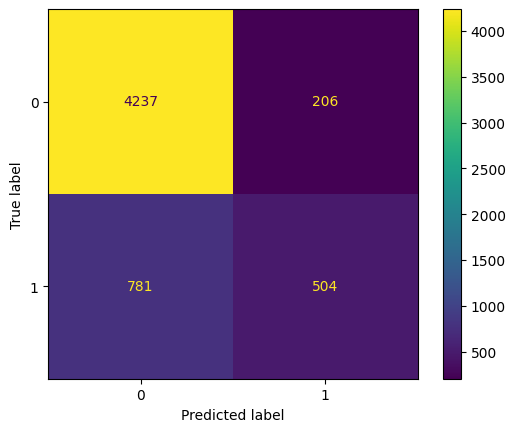

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# First, get the hard predictions (0 or 1)
y_pred = model.predict(scaler_pd.transform(x_test_pd))

# Generate and plot
cm = confusion_matrix(y_test_pd, y_pred)
ConfusionMatrixDisplay(cm).plot()

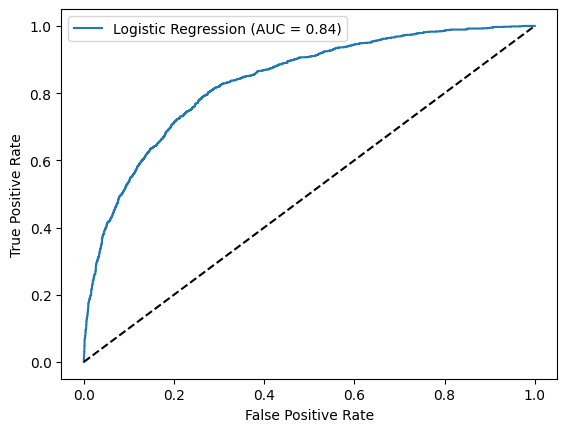

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate the AUC
y_probs = model.predict_proba(scaler_pd.transform(x_test_pd))[:, 1]
auc = roc_auc_score(y_test_pd, y_probs)

# Plot the Curve
fpr, tpr, thresholds = roc_curve(y_test_pd, y_probs)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

#### GINI CALCULATION

In [9]:

gini = 2 * auc - 1

print(f"Model AUC: {auc:.4f}")
print(f"Model Gini: {gini:.4f}")

Model AUC: 0.8352
Model Gini: 0.6703


### LGD (Loss Given Default) 

In [10]:
recovery_map = {
    'A': 0.70,
    'B': 0.60,
    'C': 0.50,
    'D': 0.40,
    'E': 0.30,
    'F': 0.20,
    'G': 0.10
}

df['recovery_rate'] = df['loan_grade'].map(recovery_map)
df['LGD'] = 1 - df['recovery_rate']

### FINAL EL(Expected Loss) CALCULATION HERE

In [11]:
df['EAD'] = df['loan_amnt']

df['EL'] = df['EAD'] * df['LGD'] * df['PD']


df.head(30)




,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,PD,recovery_rate,LGD,EAD,EL
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,0.420705,0.4,0.6,35000,8834.799822
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.137123,0.6,0.4,1000,54.849205
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.980428,0.5,0.5,5500,2696.177586
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.821670,0.5,0.5,35000,14379.222611
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.796040,0.5,0.5,35000,13930.697814
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.194033,0.7,0.3,2500,145.524770
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3,0.405225,0.6,0.4,35000,5673.155640
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4,0.297844,0.6,0.4,35000,4169.818655
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2,0.134425,0.7,0.3,35000,1411.457260
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3,0.482676,0.4,0.6,1600,463.368812


In [12]:
grade_analysis = df.groupby('loan_grade')['EL'].sum()
grade_analysis.head()

loan_grade
A    2.005431e+06
B    7.686715e+06
C    8.680938e+06
D    9.474129e+06
E    4.248543e+06
Name: EL, dtype: float64

### Portfolio Level Expected Loss

In [13]:
total_EL = df['EL'].sum()
average_EL = df['EL'].mean()

print("Total Portfolio EL:", total_EL)
print("Average EL per loan:", average_EL)

Total Portfolio EL: 34378150.05170202
Average EL per loan: 1200.4382307319654


In [14]:
EL_ratio = total_EL / df['loan_amnt'].sum()
print("Portfolio Expected Loss Ratio:", EL_ratio)

Portfolio Expected Loss Ratio: 0.12431409784965185


### Stress Testing

In [15]:
df['PD_stress'] = df['PD'] * 1.20
df['LGD_stress'] = df['LGD'] * 1.10

df['EL_stress'] = df['PD_stress'] * df['LGD_stress'] * df['loan_amnt']

stressed_total_EL = df['EL_stress'].sum()

print("Stressed EL:", stressed_total_EL)

Stressed EL: 45379158.06824666


In [16]:
impact = stressed_total_EL - total_EL
print("Increase in Loss under stress:", impact)

Increase in Loss under stress: 11001008.01654464
